### FEATURE ENGINEERING PIPELINE – TTC Delay Prediction Project
<div style="font-size: 12.5px;">
  <h4>PURPOSE:</h4>
  <p>
    This script transforms raw and cleaned datasets into a machine learning-ready dataset.
    It combines multiple data sources and generates features required for predicting bus delay risk.
  </p>

  <h4>INPUT DATA SOURCES:</h4>
  <ul>
    <li>TTC Bus Delay historical data (2022–2025)</li>
    <li>GTFS data (routes, stops, schedules, geometry)</li>
    <li>Weather data (temperature, precipitation, conditions)</li>
  </ul>

  <h4>CORE PURPOSE:</h4>
  <ul>
    <li>Merge all datasets into a single unified training table</li>
    <li>Create meaningful features from time, route, and weather</li>
    <li>Prepare structured dataset for machine learning model training</li>
  </ul>

  <h4>FEATURE ENGINEERING INCLUDES:</h4>
  <ul>
    <li>Route-level merging using GTFS information</li>
    <li>Weather feature integration (temperature, precipitation, etc.)</li>
    <li>Time-based features (hour, day of week, etc.)</li>
  </ul>

  <h4>OUTPUT:</h4>
  <p>
    Final ML-ready dataset stored in:
    <code>data/cache/final_training_data.csv</code>
  </p>
</div>

In [48]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import pickle
from sklearn.neighbors import BallTree
import matplotlib.pyplot as plt

#### CONFIG

In [55]:
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
OUTPUT_DIR = DATA_DIR / "output"
CACHE_DIR = DATA_DIR / "cache"

TTC_DIR = RAW_DIR / "ttc_bus"
WEATHER_DIR = RAW_DIR / "weather"
GTFS_DIR = RAW_DIR / "ttc_gtfs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

#### LOAD DATA

In [56]:
# TTC Bus Delay Records 
df_2022 = pd.read_excel(TTC_DIR / "ttc-bus-delay-data-2022.xlsx")
df_2023 = pd.read_excel(TTC_DIR / "ttc-bus-delay-data-2023.xlsx")
df_2024 = pd.read_excel(TTC_DIR / "ttc-bus-delay-data-2024.xlsx")
df_2025 = pd.read_csv(TTC_DIR / "ttc-bus-delay-data-since-2025.csv")

# Historical Weather data
weather_df = pd.read_csv(WEATHER_DIR / "toronto_weather_2022_2025.csv")

# GTFS data
routes_df = pd.read_csv(GTFS_DIR / "routes.txt")
trips_df = pd.read_csv(GTFS_DIR / "trips.txt")
stops_df = pd.read_csv(GTFS_DIR / "stops.txt")
stop_times_df = pd.read_csv(GTFS_DIR / "stop_times.txt")

C:\Users\amras\AppData\Local\Temp\ipykernel_49928\34326791.py:8: DtypeWarning: Columns (11,13,15,17,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv(WEATHER_DIR / "toronto_weather_2022_2025.csv")


In [57]:
# print("\nWeather")
# print(weather_df.shape)
# print(weather_df.columns.tolist())
# print("\nRoutes")
# print(routes_df.shape)
# print(routes_df.columns.tolist())
# print("\nTrips")
# print(trips_df.shape)
# print(trips_df.columns.tolist())
# print("\nStops")
# print(stops_df.shape)
# print(stops_df.columns.tolist())
# print("\nStop Times")
# print(stop_times_df.shape)
# print(stop_times_df.columns.tolist())

##### STANDARDIZE 2025 SCHEMA TO MATCH 2022-2024

In [58]:
# 2025 files have different column names than 2022-2024
# This step converts 2025 columns to match the format
# Map: Line→Route, Station→Location, Code→Incident, Bound→Direction
def standardize_schema(bus_df):
    bus_df = bus_df.copy()
    
    # Extract route number from "Line" column
    if "Line" in bus_df.columns:
        bus_df["Route"] = bus_df["Line"].astype(str).str.extract(r"(\d+)")[0]

    # Rename columns to match 2022-2024 schema
    bus_df = bus_df.rename(columns={"Station": "Location", "Code": "Incident", "Bound": "Direction"})
    return bus_df

# Standardize 2025 and combine all years
bus_frames = []
df_2025 = standardize_schema(df_2025)
# append to bus_frame
bus_frames.append(df_2025)
bus_frames.append(df_2024)
bus_frames.append(df_2023)
bus_frames.append(df_2022)
bus_df = pd.concat(bus_frames, ignore_index=True)

print(bus_df.columns.tolist())

['_id', 'Date', 'Line', 'Time', 'Day', 'Location', 'Incident', 'Min Delay', 'Min Gap', 'Direction', 'Vehicle', 'Route']


#### DATA PROCESSING: CLEAN BUS DELAY DATA

In [59]:
# Cleaning: standardize columns, parse dates, validate numeric fields, normalize text, map incidents
def clean_bus_delays(bus_df):
    bus_df = bus_df.copy()
    # Standardize column names to lowercase with underscores
    bus_df.columns = (bus_df.columns.str.strip().str.replace(" ", "_").str.lower())
    
    # Drop unnecessary columns
    # keep ['Date', 'Route', 'Time', 'Day', 'Location', 'Incident', 'Min Delay', 'Min Gap', 'Direction']
    drop_cols = ["line", "station", "_id", "vehicle", "bound", "code"]
    bus_df = bus_df.drop(columns=[c for c in drop_cols if c in bus_df.columns])

    # ---- Parse date/time ----
    bus_df["date"] = pd.to_datetime(bus_df["date"], errors="coerce")
    # combine date and time into one datetime column
    # Bus delay depends heavily on exact timestamp
    bus_df["datetime"] = pd.to_datetime(bus_df["date"].dt.strftime("%Y-%m-%d") + " " + bus_df["time"].astype(str), errors="coerce")
    # drop rows where date failed to parse entirely
    bus_df = bus_df.dropna(subset=["date"])

    # ---- Route Validation ----
    # Must be numeric and valid TTC route
    bus_df["route"] = pd.to_numeric(bus_df["route"], errors="coerce")
    bus_df = bus_df.dropna(subset=["route"])
    bus_df["route"] = bus_df["route"].astype(int)

    # ---- Delay/gap validation ----
    # Convert to numeric, drop invalid
    bus_df["min_delay"] = pd.to_numeric(bus_df["min_delay"], errors="coerce")
    bus_df["min_gap"] = pd.to_numeric(bus_df["min_gap"], errors="coerce")
    bus_df = bus_df.dropna(subset=["min_delay", "min_gap"])

    # Remove extreme outliers (errors in data) 
    # 120 min delay = long recovery, acceptable threshold
    # 240 min gap = very long headway, acceptable threshold
    bus_df = bus_df[(bus_df["min_delay"] >= 0) & (bus_df["min_delay"] < 120)]
    bus_df = bus_df[(bus_df["min_gap"] >= 0) & (bus_df["min_gap"] < 240)]

    # ---- Direction Validation ----
    # Standardize text, keep missing as "Unknown"
    valid_directions = ["N", "S", "E", "W", "UNKNOWN"]
    bus_df["direction"] = np.where(bus_df["direction"].isin(valid_directions), bus_df["direction"], "UNKNOWN")

    # Clean text formatting 
    bus_df["incident"] = bus_df["incident"].astype(str).str.strip()
    bus_df["location"] = bus_df["location"].astype(str).str.strip()
    bus_df["day"] = bus_df["day"].astype(str).str.strip().str.title()

    # ---- Incident Mapping ----
    # TTC incident descriptions vary across years
    # To ensure consistency for machine learning, all incidents are mapped into a common set of operational categories
    bus_df["incident_raw"] = bus_df["incident"].astype(str).str.strip().str.upper()

    incident_mapping = {
        # Mechanical / Vehicle
        "MECHANICAL": "Mechanical / Vehicle Failure",
        "MFO": "Mechanical / Vehicle Failure",     
        "EFO": "Mechanical / Vehicle Failure",
        "EFB": "Mechanical / Vehicle Failure",
        "EFD": "Mechanical / Vehicle Failure",
        "EFDB": "Mechanical / Vehicle Failure",
        "EFHV": "Mechanical / Vehicle Failure",
        "EFHVA": "Mechanical / Vehicle Failure",
        "EFLV": "Mechanical / Vehicle Failure",
        "EFP": "Mechanical / Vehicle Failure",
        "EFT": "Mechanical / Vehicle Failure",
        "EFTB": "Mechanical / Vehicle Failure",
        # Operations / Scheduling
        "EFCAN": "Operations / Scheduling",
        "GENERAL DELAY": "Operations / Scheduling",
        "MFUS": "Operations / Scheduling",
        "MFGD": "Operations / Scheduling",
        "TFLF": "Operations / Scheduling",
        "TFLL": "Operations / Scheduling",
        "OPERATIONS - OPERATOR": "Operations / Scheduling",
        "UTILIZED OFF ROUTE": "Diversion / Routing", # Off-route diversion
        # Security / Police
        "SECURITY": "Security / Police",
        "SFAE": "Security / Police",
        "SFAP": "Security / Police",
        "SFBT": "Security / Police",
        "SFDP": "Security / Police",
        "SFO": "Security / Police",
        "SFPOL": "Security / Police",
        "SFSA": "Security / Police",
        "SFSP": "Security / Police",
        # Collision
        "COLLISION - TTC": "Collision / Accident",
        "MFPI": "Collision / Accident",
        "PFPD": "Collision / Accident",
        "TFPD": "Collision / Accident",
        "TFPI": "Collision / Accident",
        # Emergency
        "MFS": "Emergency Services",
        "EMERGENCY SERVICES": "Emergency Services",
        # Road / Infrastructure
        "EFRA": "Road / Infrastructure Issue",
        "TFO": "Road / Infrastructure Issue",
        "MFPR": "Investigation / Held",
        "ROAD BLOCKED - NON-TTC COLLISION": "Road / Infrastructure Issue",
        # Diversion
        "DIVERSION": "Diversion / Routing",
        "MFDV": "Diversion / Routing",
        # Cleaning
        "MFCN": "Cleaning / Sanitation",
        "MFSAN": "Cleaning / Sanitation",
        "CLEANING - UNSANITARY": "Cleaning / Sanitation",
        "CLEANING - DISINFECTION": "Cleaning / Sanitation",
        # Medical / Passenger
        "MFUI": "Medical / Passenger Health",
        "MFUIR": "Medical / Passenger Health",
        "TFOI": "Medical / Passenger Health",
        # Vision
        "MFVIS": "Vision / Visibility",
        "VISION": "Vision / Visibility",
        # Investigation
        "INVESTIGATION": "Investigation / Held",
        "HELD BY": "Investigation / Held",
        "MFPR": "Investigation / Held",
        "SFPOL": "Investigation / Held",
        # Weather
        "MFWEA": "Weather Related",
        # Staffing
        "TFCNO": "Staffing / Operator Issue",
        "MFTO": "Staffing / Operator Issue",
        "MFESA": "Staffing / Operator Issue",
        "LATE ENTERING SERVICE": "Staffing / Operator Issue",
        # Fare/Admin
        "MFFD": "Fare / Administrative",
        # Miscellaneous Facilities/Station Hazards
        "MFSH": "Road / Infrastructure Issue"
    }

    # Create standardized incident category
    bus_df["incident_category"] = (bus_df["incident_raw"].map(incident_mapping).fillna("Other"))
    
    # Drop duplicate rows
    bus_df = bus_df.drop_duplicates()
    return bus_df.reset_index(drop=True)

bus_df_clean = clean_bus_delays(bus_df)

<div style="background-color:#d2f0c5; font-size:12.5px; padding:5px">
<p><b>Note:</b><br>
Zero-delay records (min_delay = 0) were analyzed and retained in the dataset. Although they do not represent active delay events, they are important for modeling normal operational conditions of the transit system. Keeping these records ensures that the machine learning model learns the difference between normal service and delayed operations, reducing bias toward overestimating delays and improving real-world prediction accuracy.</p></div>

In [60]:
# unmapped = bus_df_clean[bus_df_clean["incident_category"] == "Other"]["incident_raw"].value_counts()
# print(f"\nUnmapped incidents:")
# print(unmapped.head(100))

##### FILTER TO VALID GTFS ROUTES

In [61]:
# Route identifiers were validated against official TTC GTFS routes
# Ensure route IDs are strings for consistent matching
# Records with unknown route numbers are removed
routes_df["route_id"] = routes_df["route_id"].astype(str)
routes_df["route_short_name"] = routes_df["route_short_name"].astype(str)
valid_routes = set(routes_df["route_short_name"])

# Count invalid routes before filtering
before_rows = len(bus_df_clean)
bus_df_clean = bus_df_clean[bus_df_clean["route"] != 0] # Remove route 0 (invalid)
# Keep only routes that exist in GTFS
bus_df_clean = bus_df_clean[bus_df_clean["route"].astype(str).isin(valid_routes)]

print(f"Routes removed: {before_rows - len(bus_df_clean):,}")
print(f"Remaining rows: {len(bus_df_clean):,}\n")

Routes removed: 4,275
Remaining rows: 244,771



<div style="background-color:#d2f0c5; font-size:12.5px; padding:5px">
<p><b>Note:</b><br>
Approximately 1.7% of records contained route values that could not be matched to any valid TTC route. These records were removed to ensure consistency between historical delay data and GTFS-derived route features used in the prediction model.</p></div>

##### SELECT TOP 50 ROUTES BY IMPACT

In [62]:
# Calculate route statistics
route_stats = bus_df_clean.groupby("route").agg({"min_delay": ["sum", "mean", "count"]}).reset_index()
route_stats.columns = ["route", "total_delay", "avg_delay", "incident_count"]

# Priority routes (high-demand TTC routes)
priority_routes = ["7", "24", "25", "29", "35", "39", "60", "100", "165", "924", "925", "929"]

# Add highest-impact routes to reach 50 total
remaining_routes = route_stats[~route_stats["route"].astype(str).isin(priority_routes)] # Remove priority routes from ranking pool
top_remaining = remaining_routes.sort_values(by="total_delay", ascending=False).head(50 - len(priority_routes))
final_routes = priority_routes + top_remaining["route"].astype(str).tolist()

# Filter bus data to only selected routes
bus_df_clean = bus_df_clean[bus_df_clean["route"].astype(str).isin(final_routes)].copy()

print(f"Selected {len(final_routes)} routes:")
print(sorted([int(r) for r in final_routes]))

Selected 50 routes:
[7, 11, 12, 24, 25, 29, 32, 34, 35, 36, 37, 38, 39, 40, 41, 43, 45, 47, 52, 53, 54, 59, 60, 63, 68, 72, 73, 79, 84, 85, 86, 89, 94, 95, 96, 97, 100, 102, 108, 110, 116, 123, 129, 133, 165, 924, 925, 929, 939, 960]


#### FEATURE ENGINEERING: BUS DELAY DATA - TIME-BASED FEATURES

In [63]:
# Time-based features
bus_df_clean["hour"] = bus_df_clean["datetime"].dt.hour
bus_df_clean["month"] = bus_df_clean["datetime"].dt.month
bus_df_clean["year"] = bus_df_clean["datetime"].dt.year
bus_df_clean["is_weekend"] = bus_df_clean["day"].isin(["Saturday", "Sunday"]).astype(int)
bus_df_clean["is_rush_hour"] = bus_df_clean["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)
bus_df_clean["day_of_week"] = bus_df_clean["datetime"].dt.dayofweek
bus_df_clean["season"] = ((bus_df_clean["month"] % 12 + 3) // 3) # Season: 1=Winter 2=Spring 3=Summer 4=Fall

In [64]:
print("Bus Delay Cleaning Summary")
print(f"Rows: {bus_df_clean.shape[0]}")
print(f"Missing location: {bus_df_clean['location'].isna().sum()}")
print(f"Missing incident: {bus_df_clean['incident'].isna().sum()}")
print(f"Unique routes: {bus_df_clean['route'].nunique()}")
print(f"Route range: {bus_df_clean['route'].min()} - {bus_df_clean['route'].max()}")
print(f"\nIncident value counts:\n{bus_df_clean['incident_category'].value_counts()}")

Bus Delay Cleaning Summary
Rows: 152088
Missing location: 0
Missing incident: 0
Unique routes: 50
Route range: 7 - 960

Incident value counts:
incident_category
Mechanical / Vehicle Failure    52563
Operations / Scheduling         33575
Diversion / Routing             11389
Collision / Accident            10400
Security / Police               10193
Road / Infrastructure Issue      7526
Staffing / Operator Issue        5962
Cleaning / Sanitation            5250
Emergency Services               5037
Vision / Visibility              3530
Medical / Passenger Health       3163
Investigation / Held             2392
Weather Related                   662
Other                             445
Fare / Administrative               1
Name: count, dtype: int64


#### DATA PROCESSING: CLEAN WEATHER DATA

In [82]:
# Parse weather data, fill missing values, aggregate to hourly
def clean_weather(weather_df):
    weather_df = weather_df.copy()
    # Standardize column names
    weather_df.columns = weather_df.columns.str.lower().str.strip()

    # Parse datetime
    weather_df["datetime"] = pd.to_datetime(weather_df["date/time (lst)"], errors="coerce")
    weather_df = weather_df.dropna(subset=["datetime"]) # Drop invalid timestamps

    # Keep relevant columns
    cols = ["datetime", "temp (°c)", "rel hum (%)", "precip. amount (mm)", "wind spd (km/h)", "visibility (km)"]
    weather_df = weather_df[[c for c in cols if c in weather_df.columns]]

    # Convert to numeric
    num_cols = [c for c in weather_df.columns if c != "datetime"]
    for col in num_cols:
        weather_df[col] = pd.to_numeric(weather_df[col], errors="coerce")

    # Forward fill missing values
    weather_df[num_cols] = weather_df[num_cols].ffill()

    # Aggregate to hourly (take median for stability)
    weather_df["hour_dt"] = weather_df["datetime"].dt.floor("h")
    weather_hourly = weather_df.groupby("hour_dt")[num_cols].median().reset_index()
    weather_hourly.columns = ["hour_dt", "temp_celsius", "humidity_pct", 
                              "precipitation_mm", "wind_speed_kmh", "visibility_km"]

    return weather_hourly

weather_clean = clean_weather(weather_df)
print(f"Weather data cleaned: {len(weather_clean):,}")

Weather data cleaned: 35,064


In [66]:
print("Weather validation check\n")
print("\nMissing values:")
print(weather_clean.isnull().sum())
print("\nSummary statistics:")
print(weather_clean.describe())

Weather validation check


Missing values:
hour_dt             0
temp_celsius        0
humidity_pct        0
precipitation_mm    0
wind_speed_kmh      0
visibility_km       0
dtype: int64

Summary statistics:
                   hour_dt  temp_celsius  humidity_pct  precipitation_mm  \
count                35064  35064.000000  35064.000000      35064.000000   
mean   2024-01-01 11:30:00      9.855051     73.084588          0.079298   
min    2022-01-01 00:00:00    -20.000000     16.000000          0.000000   
25%    2023-01-01 05:45:00      2.300000     63.000000          0.000000   
50%    2024-01-01 11:30:00      9.400000     74.000000          0.000000   
75%    2024-12-31 17:15:00     18.600000     84.000000          0.000000   
max    2025-12-31 23:00:00     34.400000    100.000000         43.700000   
std                    NaN      9.652050     14.764511          0.635400   

       wind_speed_kmh  visibility_km  
count    35064.000000   35064.000000  
mean        18.069986      1

#### MERGE WEATHER INTO BUS DATA

In [67]:
 # Create hourly key for joining
bus_df_clean["hour_dt"] = bus_df_clean["datetime"].dt.floor("h")
# Merge weather
bus_df_clean = bus_df_clean.merge(weather_clean, on="hour_dt", how="left")

# Fill missing weather with medians (safety)
bus_df_clean["temp_celsius"] = bus_df_clean["temp_celsius"].fillna(bus_df_clean["temp_celsius"].median())
bus_df_clean["humidity_pct"] = bus_df_clean["humidity_pct"].fillna(bus_df_clean["humidity_pct"].median())
bus_df_clean["precipitation_mm"] = bus_df_clean["precipitation_mm"].fillna(0)
bus_df_clean["wind_speed_kmh"] = bus_df_clean["wind_speed_kmh"].fillna(bus_df_clean["wind_speed_kmh"].median())
bus_df_clean["visibility_km"] = bus_df_clean["visibility_km"].fillna(bus_df_clean["visibility_km"].median())

#### FEATURE ENGINEERING: BUS DELAY DATA - CREATE DELAY TARGETS

In [83]:
# Delay flag: any delay > 0 minutes
bus_df_clean["is_delay"] = (bus_df_clean["min_delay"] > 0).astype(int)
# Major delay flag: >= 20 minutes (TTC threshold)
bus_df_clean["is_major_delay"] = (bus_df_clean["min_delay"] >= 20).astype(int) # target 1

print(f"Delay rate: {bus_df_clean['is_delay'].mean():.1%}")
print(f"Major delay rate: {bus_df_clean['is_major_delay'].mean():.1%}")

Delay rate: 99.9%
Major delay rate: 23.6%


##### CREATE SERVICE IRREGULARITY FEATURES (GAPPING/BUNCHING)

<div style="background-color:#d2f0c5; font-size:12.5px; padding:5px">
<p><b>Note:</b><br>
<b>Two service irregularity patterns are identified:</b><br>
    
* GAPPING: A bus headway that exceeds the 75th percentile for the dataset. Indicates a long passenger wait.
* BUNCHING-LIKE: A bus with a shorter-than-median headway immediately following a longer-than-median headway on the same route. Mimics operational bus bunching (a bus "catching up").
</div>

In [84]:
# Remove impossible gaps (min_gap = 0 indicates data error)
bus_df_clean = bus_df_clean[bus_df_clean["min_gap"] > 0].copy()
# Sort by route and datetime for lagged calculations
bus_df_clean = bus_df_clean.sort_values(["route", "datetime"]).reset_index(drop=True)

# ---- GAPPING: Long headways ----
# Gapping indicates long wait times between buses
gapping_threshold = bus_df_clean["min_gap"].quantile(0.75) # finds the 75th percentile
bus_df_clean["is_gapped"] = (bus_df_clean["min_gap"] > gapping_threshold).astype(int) # target 2

# ---- BUNCHING-LIKE: Short headway after long headway ----
# Operational bunching occurs when a bus catches up after a gap
# Route-specific short gap following route-specific long gap
route_medians = bus_df_clean.groupby("route")["min_gap"].median().to_dict() # normal gap for each route

# Find the previous gap
bus_df_clean["prev_gap"] = bus_df_clean.groupby("route")["min_gap"].shift(1)

# pattern is Long gap -> Very short gap
bus_df_clean["is_bunching_like"] = ((bus_df_clean["min_gap"] < bus_df_clean["route"].map(route_medians)) & # target 3
    (bus_df_clean["prev_gap"] > bus_df_clean["route"].map(route_medians))).astype(int).fillna(0)

print(f"Gapping rate (>Q3): {bus_df_clean['is_gapped'].mean():.1%}")
print(f"Bunching-like rate: {bus_df_clean['is_bunching_like'].mean():.1%}")

Gapping rate (>Q3): 22.9%
Bunching-like rate: 12.1%


#### FEATURE ENGINEERING: CREATE WEATHER FEATURE FLAGS

In [74]:
bus_df_clean["is_rainy"] = (bus_df_clean["precipitation_mm"] > 0).astype(int)
bus_df_clean["is_heavy_rain"] = (bus_df_clean["precipitation_mm"] > 5).astype(int)
bus_df_clean["is_cold"] = (bus_df_clean["temp_celsius"] < 0).astype(int)
bus_df_clean["is_hot"] = (bus_df_clean["temp_celsius"] > 25).astype(int)
bus_df_clean["low_visibility"] = (bus_df_clean["visibility_km"] < 5).astype(int)
bus_df_clean["high_wind"] = (bus_df_clean["wind_speed_kmh"] > 30).astype(int)

# Combined weather intensity score
bus_df_clean["weather_intensity"] = (bus_df_clean["precipitation_mm"] * 0.5 + (bus_df_clean["wind_speed_kmh"] / 20) +
    bus_df_clean["is_rainy"] + bus_df_clean["is_cold"])

### FOUR-LEVEL ANALYSIS METRICS (route, stop, time, hotspot)

In [101]:
# For the report purpose and Descriptive + Diagnostic Analytics

# SERVICE IRREGULARITY ANALYSIS
#   Level 1: Route-level metrics
#   Level 2: Stop-level metrics (route x location)
#   Level 3: Time-level metrics (by hour of day)
#   Level 4: Hotspot metrics (route x location x hour)

# LEVEL 1: ROUTE METRICS
route_metrics = bus_df_clean.groupby("route").agg({"min_gap": ["mean", "median", "std"],
    "min_delay": ["mean", "median", "std"], "is_major_delay": "mean",
    "is_gapped": "mean", "is_bunching_like": "mean",
    "datetime": "count"}).round(3)
route_metrics.columns = ["avg_gap","median_gap","gap_std","avg_delay","median_delay","delay_std",
    "major_delay_rate","gapping_rate","bunching_rate","n_incidents"]
route_metrics = route_metrics[route_metrics["n_incidents"] >= 100]
route_metrics = route_metrics.sort_values(["bunching_rate","gapping_rate","major_delay_rate","n_incidents"], ascending=[False,False,False,False])

print(f"\nTOP 5 ROUTES WITH HIGHEST BUNCHING")
for route,row in route_metrics.head(5).iterrows():
    print(f"Route {route} | "f"Bunching={row['bunching_rate']:.1%} | "
        f"Gapping={row['gapping_rate']:.1%} | "f"Major Delay={row['major_delay_rate']:.1%} | "f"Incidents={int(row['n_incidents'])}")

# LEVEL 2: STOP METRICS
stop_metrics = bus_df_clean.groupby(["route","location"]).agg({"min_gap":["mean","median"], "min_delay":["mean","median"],
    "is_major_delay":"mean", "is_gapped":"mean", "is_bunching_like":"mean", "datetime":"count"}).round(3)
stop_metrics.columns = ["avg_gap","median_gap", "avg_delay","median_delay", "major_delay_rate", "gapping_rate", "bunching_rate", "n_incidents"]
stop_metrics = stop_metrics.reset_index()
stop_metrics = stop_metrics[stop_metrics["n_incidents"] >= 100]
stop_metrics = stop_metrics.sort_values(["bunching_rate","gapping_rate","major_delay_rate","n_incidents"], ascending=[False,False,False,False])

print(f"\nTOP 5 STOPS WITH HIGHEST BUNCHING")
for _,row in stop_metrics.head(5).iterrows():
    print(f"Route {row['route']} | "f"{row['location']} | "
        f"Bunching={row['bunching_rate']:.1%} | "f"Gapping={row['gapping_rate']:.1%} | "
        f"Major Delay={row['major_delay_rate']:.1%} | "f"Incidents={int(row['n_incidents'])}")

# LEVEL 3: TIME METRICS
time_metrics = bus_df_clean.groupby("hour").agg({"min_gap":["mean","median"], "min_delay":["mean","median"],
    "is_major_delay":"mean", "is_gapped":"mean", "is_bunching_like":"mean", "datetime":"count"}).round(3)
time_metrics.columns = ["avg_gap", "median_gap", "avg_delay", "median_delay", "major_delay_rate", "gapping_rate", "bunching_rate", "n_incidents"]
time_metrics = time_metrics.sort_values(["bunching_rate","gapping_rate","major_delay_rate"], ascending=False)

print(f"\nTOP 10 HOURS WITH HIGHEST BUNCHING")
for hour,row in time_metrics.head(10).iterrows():
    print(f"{hour:02d}:00 | "f"Bunching={row['bunching_rate']:.1%} | "
        f"Gapping={row['gapping_rate']:.1%} | "f"Major Delay={row['major_delay_rate']:.1%} | "f"Incidents={int(row['n_incidents'])}")

# LEVEL 4: HOTSPOT METRICS
hotspot_metrics = bus_df_clean.groupby(["route","location","hour"]).agg({"min_gap":"mean", "min_delay":["mean","median"],
    "is_major_delay":"mean", "is_gapped":"mean", "is_bunching_like":"mean", "datetime":"count"}).round(3)
hotspot_metrics.columns = ["avg_gap", "avg_delay", "median_delay", "major_delay_rate", "gapping_rate", "bunching_rate","n_incidents"]
hotspot_metrics = hotspot_metrics.reset_index()
hotspot_metrics = hotspot_metrics[hotspot_metrics["n_incidents"] >= 20]
hotspot_metrics = hotspot_metrics.sort_values(["bunching_rate","gapping_rate","major_delay_rate","n_incidents"], ascending=[False,False,False,False])

print(f"\nTOP 5 BUNCHING HOTSPOTS")
for _,row in hotspot_metrics.head(5).iterrows():
    print(f"Route {row['route']} | "
        f"{row['location']} | "f"{int(row['hour']):02d}:00 | "f"Bunching={row['bunching_rate']:.1%} | "f"Gapping={row['gapping_rate']:.1%} | "
        f"Major Delay={row['major_delay_rate']:.1%} | "f"Incidents={int(row['n_incidents'])}")

route_metrics.to_csv(OUTPUT_DIR/"01_route_metrics.csv")
stop_metrics.to_csv(OUTPUT_DIR/"02_stop_metrics.csv")
time_metrics.to_csv(OUTPUT_DIR/"03_time_metrics.csv")
hotspot_metrics.to_csv(OUTPUT_DIR/"04_hotspot_clusters.csv")

# Note based on analysis to improve code:
# add time-phase feature, allow the model to capture system startup behavior (5AM bunching) - remove is_rush_hour


TOP 5 ROUTES WITH HIGHEST BUNCHING
Route 123 | Bunching=22.4% | Gapping=50.4% | Major Delay=51.1% | Incidents=1467
Route 52 | Bunching=19.7% | Gapping=51.3% | Major Delay=50.9% | Incidents=6272
Route 59 | Bunching=19.6% | Gapping=76.7% | Major Delay=79.4% | Incidents=933
Route 39 | Bunching=19.5% | Gapping=18.2% | Major Delay=18.1% | Incidents=2667
Route 47 | Bunching=19.3% | Gapping=30.9% | Major Delay=29.4% | Incidents=3319

TOP 5 STOPS WITH HIGHEST BUNCHING
Route 86 | MEADOWVALE LOOP | Bunching=34.4% | Gapping=3.1% | Major Delay=3.1% | Incidents=128
Route 52 | PEARSON AIRPORT TERMIN | Bunching=29.2% | Gapping=45.1% | Major Delay=46.0% | Incidents=113
Route 102 | MORNINGSIDE AND PASSMO | Bunching=28.8% | Gapping=8.1% | Major Delay=13.1% | Incidents=160
Route 102 | MARKHAM AND STEELES | Bunching=27.6% | Gapping=19.0% | Major Delay=25.3% | Incidents=174
Route 47 | LANSDOWNE AND ST CLAIR | Bunching=26.3% | Gapping=24.8% | Major Delay=26.3% | Incidents=133

TOP 10 HOURS WITH HIGHEST BUN

#### SUMMARY VISUALISATIONS

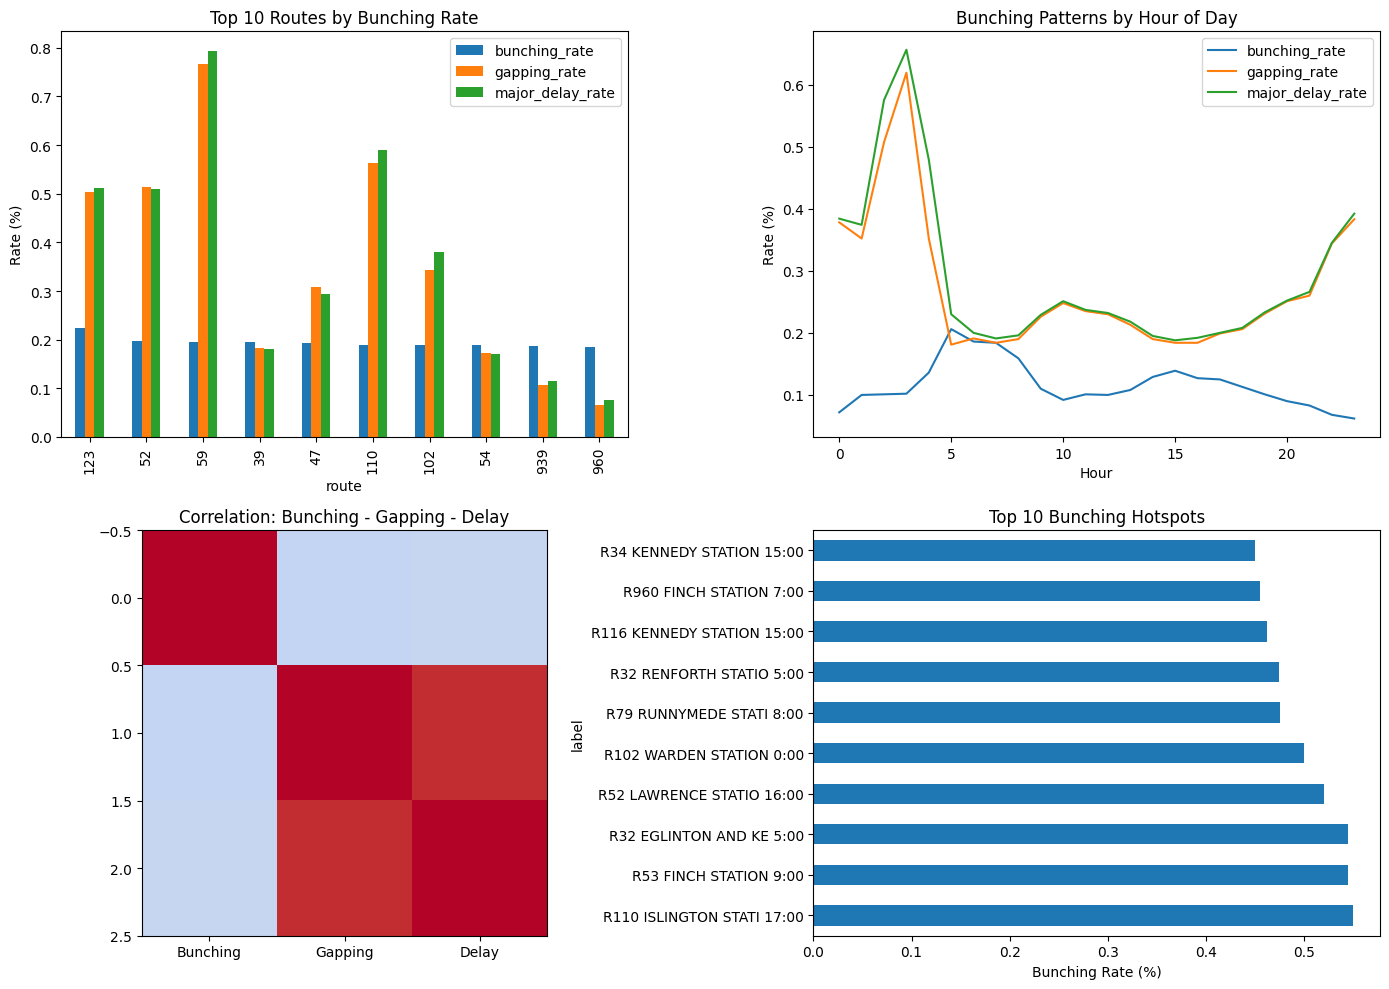

In [102]:
# For understanding and report purposes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# # Plot 1: Top 10 routes by bunching rate
route_metrics.head(10).plot(y=["bunching_rate", "gapping_rate", "major_delay_rate"], kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Top 10 Routes by Bunching Rate")
axes[0, 0].set_ylabel("Rate (%)")
# Plot 2: Bunching patterns across hours of the day
time_metrics.sort_index().plot(y=["bunching_rate", "gapping_rate", "major_delay_rate"], ax=axes[0, 1])
axes[0, 1].set_title("Bunching Patterns by Hour of Day")
axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_ylabel("Rate (%)")
# Plot 3: Correlation heatmap (bunching / gapping / delay)
corr_data = bus_df_clean[["is_bunching_like", "is_gapped", "is_major_delay"]].corr()
axes[1, 0].imshow(corr_data, cmap="coolwarm", vmin=-1, vmax=1)
axes[1, 0].set_title("Correlation: Bunching - Gapping - Delay")
axes[1, 0].set_xticks([0, 1, 2])
axes[1, 0].set_xticklabels(["Bunching", "Gapping", "Delay"])
# Plot 4: Hotspot top 10
hotspot_top = hotspot_metrics.head(10).copy()
hotspot_top["label"] = ("R" + hotspot_top["route"].astype(str) + " " + hotspot_top["location"].str[:15] + 
    " " + hotspot_top["hour"].astype(int).astype(str) + ":00")
hotspot_top.plot(y="bunching_rate", x="label", kind="barh", ax=axes[1, 1], legend=False)
axes[1, 1].set_title("Top 10 Bunching Hotspots")
axes[1, 1].set_xlabel("Bunching Rate (%)")

plt.tight_layout()

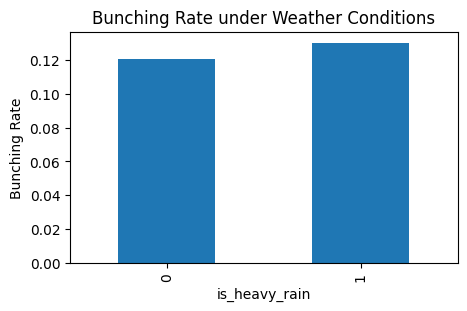

In [109]:
fig, ax = plt.subplots(figsize=(5,3))

bus_df_clean.groupby("is_heavy_rain")["is_bunching_like"].mean().plot(kind="bar", ax=ax)
ax.set_title("Bunching Rate under Weather Conditions")
ax.set_ylabel("Bunching Rate")

plt.show()

#### STATISTICAL VALIDATION OF IRREGULARITY DEFINITIONS

In [111]:
# Each target label is validated: does it meaningfully correlate with delays?
# All three pass a two-sample t-test at p < 0.001
df = bus_df_clean.copy()
df = df[df["min_gap"] > 0]

# GAPPING VALIDATION
g_thresh = df["min_gap"].quantile(0.75)
df["is_gapped"] = (df["min_gap"] > g_thresh).astype(int)
g1 = df[df["is_gapped"] == 1]["min_delay"]
g0 = df[df["is_gapped"] == 0]["min_delay"]
print("\nGapping Validation")
print("Avg delay (gapped):", g1.mean())
print("Avg delay (normal):", g0.mean())
print("p-value:", stats.ttest_ind(g1, g0).pvalue)

# BUNCHING VALIDATION
route_median = df.groupby("route")["min_gap"].transform("median")
df["is_bunching"] = (df["min_gap"] < route_median).astype(int)
b1 = df[df["is_bunching"] == 1]["min_delay"]
b0 = df[df["is_bunching"] == 0]["min_delay"]
print("\nBunching Validation")
print("Avg delay (bunching):", b1.mean())
print("Avg delay (normal):", b0.mean())
print("p-value:", stats.ttest_ind(b1, b0).pvalue)

# MAJOR DELAY SUMMARY
major_rate = (df["min_delay"] >= 20).mean()
print("\nMajor Delay Rate:", major_rate)


Gapping Validation
Avg delay (gapped): 29.180412211374556
Avg delay (normal): 10.58293312274451
p-value: 0.0

Bunching Validation
Avg delay (bunching): 9.808165660937988
Avg delay (normal): 17.99581049108431
p-value: 0.0

Major Delay Rate: 0.23616876585013388


#### PREPARE FINAL ML DATASET

In [112]:
if "day_of_week" not in bus_df_clean.columns:
    bus_df_clean["day_of_week"] = bus_df_clean["datetime"].dt.dayofweek

base_features = ["route", "year", "month", "hour", "day_of_week", "is_weekend", "is_rush_hour",
    "temp_celsius", "humidity_pct", "precipitation_mm", "wind_speed_kmh", "visibility_km",
    "is_rainy", "is_heavy_rain", "is_cold", "is_hot", "low_visibility", "high_wind", "weather_intensity"]

# Build feature matrix from base features
X_clean = bus_df_clean[[c for c in base_features if c in bus_df_clean.columns]].copy()

# hot encode categorical features (as integers)
incident_dummies = pd.get_dummies(bus_df_clean["incident_category"], prefix="incident", dtype=int)
direction_dummies = pd.get_dummies(bus_df_clean["direction"], prefix="dir", dtype=int)
X_clean = pd.concat([X_clean, incident_dummies, direction_dummies], axis=1)

# Create target variables
targets = pd.DataFrame({"target_is_major_delay": bus_df_clean["is_major_delay"], "target_is_gapped": bus_df_clean["is_gapped"],
    "target_is_bunching_like": bus_df_clean["is_bunching_like"]})

# Combining features and targets
ml_dataset_clean = X_clean.copy()
ml_dataset_clean = pd.concat([ml_dataset_clean, targets], axis=1)

# Add REFERENCE column (for analysis/reporting)
ml_dataset_clean["location"] = bus_df_clean["location"]

# Verifying no data leakage
feature_cols = [c for c in ml_dataset_clean.columns 
                if c not in targets.columns and c not in ["location"]]

problematic = [col for col in feature_cols 
               if any(x in col.lower() for x in ["min_gap", "min_delay", "prev_gap", "lag_", "rolling_"])]

if problematic:
    print(f"WARNING: Found problematic features: {problematic}")
else:
    print("CLEAN: No data leakage detected")
    
# Saving ML dataset
ml_dataset_clean.to_csv(OUTPUT_DIR / "ml_dataset_ready.csv", index=False)

CLEAN: No data leakage detected


In [95]:
print(ml_dataset_clean.columns.tolist())

['route', 'year', 'month', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'temp_celsius', 'humidity_pct', 'precipitation_mm', 'wind_speed_kmh', 'visibility_km', 'is_rainy', 'is_heavy_rain', 'is_cold', 'is_hot', 'low_visibility', 'high_wind', 'weather_intensity', 'incident_Cleaning / Sanitation', 'incident_Collision / Accident', 'incident_Diversion / Routing', 'incident_Emergency Services', 'incident_Fare / Administrative', 'incident_Investigation / Held', 'incident_Mechanical / Vehicle Failure', 'incident_Medical / Passenger Health', 'incident_Operations / Scheduling', 'incident_Other', 'incident_Road / Infrastructure Issue', 'incident_Security / Police', 'incident_Staffing / Operator Issue', 'incident_Vision / Visibility', 'incident_Weather Related', 'dir_E', 'dir_N', 'dir_S', 'dir_UNKNOWN', 'dir_W', 'target_is_major_delay', 'target_is_gapped', 'target_is_bunching_like', 'location']


<div style="background-color:#d2f0c5; font-size:12.5px; padding:5px">

##### Note:
min_gap and prev_gap were intentionally excluded because the gapping and bunching targets are derived directly from headway measurements.
Including these variables would introduce data leakage: the model would be using components of the target to predict the target itself, creating circular logic and invalidating the predictive framework.
</div>

Features (39)
route
year
month
hour
day_of_week
is_weekend
is_rush_hour (Time_phase)

temp_celsius
humidity_pct
precipitation_mm
wind_speed_kmh
visibility_km

is_rainy
is_heavy_rain
is_cold
is_hot
low_visibility
high_wind
weather_intensity

incidents

directions 

Targets:
target_is_major_delay
target_is_gapped
target_is_bunching_like

In [ ]:
# my Note 
# Replace:
# ml_dataset_clean["location"] = bus_df_clean["location"]
# with:
# # Add reference columns (NOT used for training)
# ml_dataset_clean["record_id"] = bus_df_clean.index
# ml_dataset_clean["location"] = bus_df_clean["location"]
# during training:
# X = ml_dataset.drop(
#     columns=[
#         "target_is_major_delay",
#         "target_is_gapped",
#         "target_is_bunching_like",
#         "location",
#         "record_id"
#     ]
# )
# Y = ml_dataset[
#     [
#         "target_is_major_delay",
#         "target_is_gapped",
#         "target_is_bunching_like"
#     ]
# ]

# for time phase 
# Hour	Feature
# 5–8	morning_rush
# 9–15	off_peak
# 16–19	evening_peak
# 0–4	startup/night